## 5. Menentukan jumlah klaster kandidat

,k,silhouette,davies_bouldin,calinski_harabasz,inertia_sse,waktu_detik
0,2,0.1059,3.7984,25.0213,310.7241,0.1870
1,3,0.1265,3.5482,23.1387,294.9595,0.2022


K dengan Silhouette tertinggi pada rentang uji: 3
K final untuk model dan pelabelan: 3


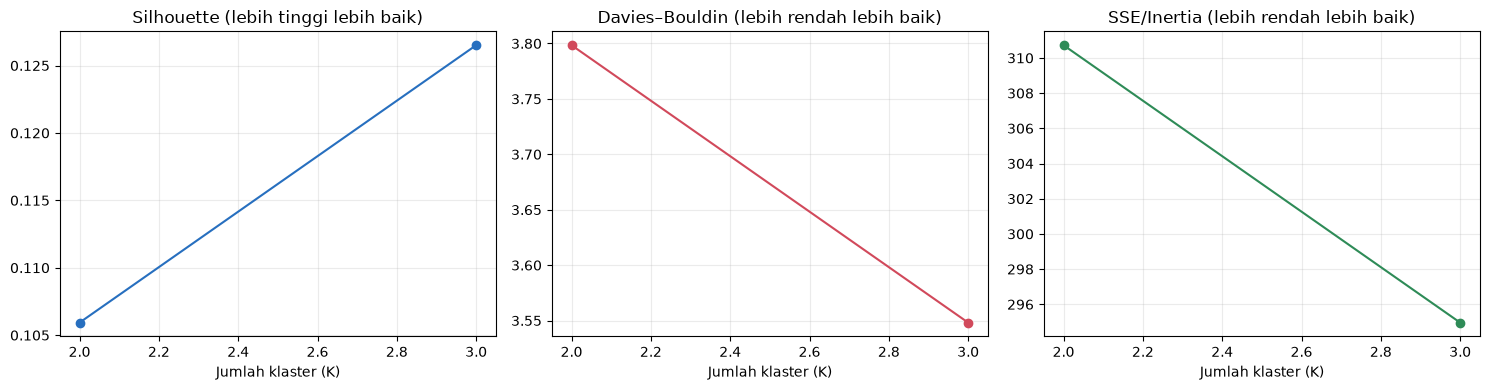

In [ ]:
# BLOK 5 — Menguji beberapa nilai K untuk menilai jumlah klaster yang paling sesuai.
# Mengumpulkan metrik internal untuk membandingkan kualitas klaster tanpa label topik acuan.
def hitung_metrik(X_eval, labels, inertia, waktu):
    # Metrik eksternal tidak tersedia karena dataset tidak memiliki label topik acuan.
    n_clusters_found = len(np.unique(labels))
    if n_clusters_found < 2:
        return {'silhouette': np.nan, 'davies_bouldin': np.nan, 'calinski_harabasz': np.nan,
                'inertia_sse': inertia, 'waktu_detik': waktu}
    return {
        'silhouette': silhouette_score(X_eval, labels, metric='cosine'),
        'davies_bouldin': davies_bouldin_score(X_eval, labels),
        'calinski_harabasz': calinski_harabasz_score(X_eval, labels),
        'inertia_sse': inertia,
        'waktu_detik': waktu,
    }

hasil_k = []
model_kandidat = {}
# Setiap kandidat K dilatih dengan konfigurasi yang sama agar perbandingannya adil.
for k in range(K_MIN, K_MAX + 1):
    mulai = time.perf_counter()
    model = KMeans(n_clusters=k, init='k-means++', n_init=20, max_iter=300, random_state=RANDOM_STATE)
    labels = model.fit_predict(X)
    durasi = time.perf_counter() - mulai
    metrik = hitung_metrik(X, labels, model.inertia_, durasi)
    hasil_k.append({'k': k, **metrik})
    model_kandidat[k] = model

df_k = pd.DataFrame(hasil_k)
# Silhouette tertinggi menjadi referensi empiris; K final tetap mengikuti kebutuhan tiga topik penelitian.
K_SILHOUETTE = int(df_k.loc[df_k['silhouette'].idxmax(), 'k'])
K_TERBAIK = K_FINAL
display(df_k.round(4))
print(f'K dengan Silhouette tertinggi pada rentang uji: {K_SILHOUETTE}')
print(f'K final untuk model dan pelabelan: {K_TERBAIK}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(df_k['k'], df_k['silhouette'], marker='o', color='#276FBF')
axes[0].set_title('Silhouette (lebih tinggi lebih baik)')
axes[1].plot(df_k['k'], df_k['davies_bouldin'], marker='o', color='#D1495B')
axes[1].set_title('Davies–Bouldin (lebih rendah lebih baik)')
axes[2].plot(df_k['k'], df_k['inertia_sse'], marker='o', color='#2E8B57')
axes[2].set_title('SSE/Inertia (lebih rendah lebih baik)')
for ax in axes:
    ax.set_xlabel('Jumlah klaster (K)')
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. K-Means standar sebagai baseline

In [ ]:
# BLOK 6 — Menetapkan K-Means acak sebagai baseline pembanding sebelum optimasi PSO.
print(f'Evaluasi akan dijalankan pada {len(EXPERIMENT_SEEDS)} seed: {EXPERIMENT_SEEDS}')
print('Baseline: K-Means random satu inisialisasi per seed.')

Evaluasi akan dijalankan pada 10 seed: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Baseline: K-Means random satu inisialisasi per seed.


## 7. Implementasi Particle Swarm Optimization

In [ ]:
# BLOK 7 — Mendefinisikan fungsi PSO dan penyempurnaan K-Means untuk mengoptimalkan centroid.
# Menghitung jarak Euclidean kuadrat seluruh data ke seluruh centroid secara tervektorisasi.
def jarak_kuadrat(X_dense, centers):
    x_norm = np.sum(X_dense * X_dense, axis=1)[:, None]
    c_norm = np.sum(centers * centers, axis=1)[None, :]
    return np.maximum(x_norm + c_norm - 2.0 * X_dense @ centers.T, 0.0)

def sse_centroid(X_dense, centers):
    return float(np.min(jarak_kuadrat(X_dense, centers), axis=1).sum())

def refinement_kmeans(X_dense, centers, n_steps=1):
    # Langkah Lloyd lokal menjaga setiap partikel tetap menjadi kandidat centroid yang layak.
    centers = centers.copy()
    for _ in range(n_steps):
        labels = np.argmin(jarak_kuadrat(X_dense, centers), axis=1)
        for j in range(len(centers)):
            anggota = X_dense[labels == j]
            if len(anggota):
                centers[j] = anggota.mean(axis=0)
    return centers

def pso_centroids(
    X_dense, n_clusters, initial_centers, n_particles=30, n_iterations=40,
    w=0.72, c1=1.49, c2=1.49, random_state=42
):
    rng = np.random.default_rng(random_state)
    n_samples, n_features = X_dense.shape
    lower, upper = X_dense.min(axis=0), X_dense.max(axis=0)

    positions = np.empty((n_particles, n_clusters, n_features), dtype=np.float64)
    # Partikel pertama memakai centroid baseline agar PSO mulai dari solusi yang sudah layak.
    positions[0] = initial_centers.copy()
    for p in range(1, n_particles):
        positions[p] = X_dense[rng.choice(n_samples, size=n_clusters, replace=False)]

    # Memetic PSO–K-Means: pemanasan lokal, lalu satu langkah Lloyd setiap iterasi PSO.
    positions = np.array([refinement_kmeans(X_dense, pos, n_steps=5) for pos in positions])
    velocities = rng.uniform(-0.03, 0.03, size=positions.shape)
    personal_best = positions.copy()
    personal_scores = np.array([sse_centroid(X_dense, pos) for pos in positions])
    best_idx = int(np.argmin(personal_scores))
    global_best = personal_best[best_idx].copy()
    global_score = float(personal_scores[best_idx])
    history = [global_score]

    for _ in range(n_iterations):
        r1, r2 = rng.random(size=positions.shape), rng.random(size=positions.shape)
        # Kecepatan menggabungkan inersia, pengalaman terbaik partikel, dan solusi terbaik kawanan.
        velocities = (w * velocities + c1 * r1 * (personal_best - positions)
                      + c2 * r2 * (global_best[None, :, :] - positions))
        # Batas kecepatan mencegah centroid melompat terlalu jauh pada satu iterasi.
        velocities = np.clip(velocities, -0.10, 0.10)
        positions = np.clip(positions + velocities, lower, upper)
        positions = np.array([refinement_kmeans(X_dense, pos, n_steps=1) for pos in positions])

        scores = np.array([sse_centroid(X_dense, pos) for pos in positions])
        # Personal best hanya diganti apabila SSE partikel benar-benar membaik.
        improved = scores < personal_scores
        personal_best[improved] = positions[improved]
        personal_scores[improved] = scores[improved]
        best_idx = int(np.argmin(personal_scores))
        if personal_scores[best_idx] < global_score:
            global_score = float(personal_scores[best_idx])
            global_best = personal_best[best_idx].copy()
        history.append(global_score)

    return global_best, global_score, history

print('Fungsi memetic PSO–K-Means siap.')

Fungsi memetic PSO–K-Means siap.


## 8. Menjalankan PSO–K-Means

,seed,metode,silhouette,davies_bouldin,calinski_harabasz,inertia_sse,waktu_detik
0,0,K-Means baseline,0.10902,3.46544,22.61567,295.69548,0.01025
1,0,PSO–K-Means,0.12270,3.53334,23.14112,294.95611,0.98986
2,1,K-Means baseline,0.12651,3.54674,23.13701,294.96188,0.11175
3,1,PSO–K-Means,0.12505,3.53558,23.15916,294.93079,0.70361
4,2,K-Means baseline,0.08747,3.76002,19.78998,299.73603,0.01221
5,2,PSO–K-Means,0.11600,3.46174,23.52553,294.41753,0.72354
6,3,K-Means baseline,0.10370,3.55916,21.77194,296.89051,0.01473
7,3,PSO–K-Means,0.11600,3.46174,23.52553,294.41753,0.66412
8,4,K-Means baseline,0.12607,3.54869,23.13065,294.97081,0.13633
9,4,PSO–K-Means,0.12578,3.54610,23.15054,294.94288,0.65382


Model pelabelan memakai PSO–K-Means terbaik pada seed 2.


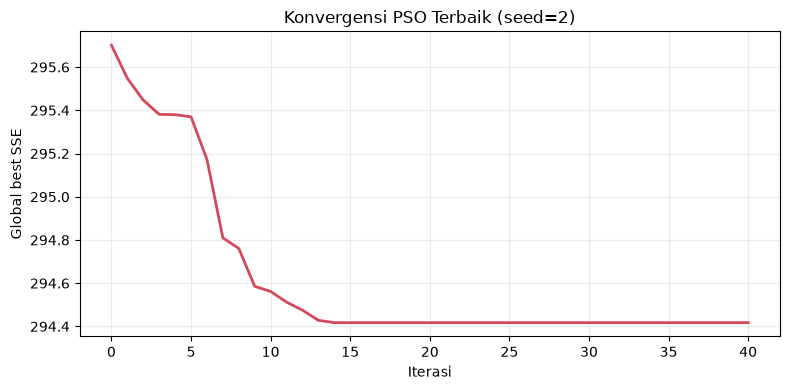

In [ ]:
# BLOK 8 — Membandingkan baseline dan PSO–K-Means pada seed yang sama, lalu memilih model terbaik.
hasil_eksperimen = []
baseline_models, pso_models, histories = {}, {}, {}

# Kedua metode memakai seed yang sama agar perbandingan dimulai dari kondisi yang setara.
for seed in EXPERIMENT_SEEDS:
    mulai = time.perf_counter()
    baseline_run = KMeans(
        n_clusters=K_TERBAIK, init='random', n_init=1, max_iter=300, random_state=seed
    ).fit(X)
    waktu_baseline = time.perf_counter() - mulai
    metrik_baseline_run = hitung_metrik(X, baseline_run.labels_, baseline_run.inertia_, waktu_baseline)

    mulai = time.perf_counter()
    centroid_pso, _, history = pso_centroids(
        X, K_TERBAIK, baseline_run.cluster_centers_, N_PARTICLES, N_ITERATIONS,
        INERTIA_WEIGHT, COGNITIVE_WEIGHT, SOCIAL_WEIGHT, seed
    )
    # K-Means final menyempurnakan centroid hasil PSO hingga konvergen dengan prosedur Lloyd.
    pso_run = KMeans(
        n_clusters=K_TERBAIK, init=centroid_pso, n_init=1, max_iter=300, random_state=seed
    ).fit(X)
    waktu_pso = time.perf_counter() - mulai
    metrik_pso_run = hitung_metrik(X, pso_run.labels_, pso_run.inertia_, waktu_pso)

    baseline_models[seed], pso_models[seed], histories[seed] = baseline_run, pso_run, history
    hasil_eksperimen.extend([
        {'seed': seed, 'metode': 'K-Means baseline', **metrik_baseline_run},
        {'seed': seed, 'metode': 'PSO–K-Means', **metrik_pso_run},
    ])

df_eksperimen = pd.DataFrame(hasil_eksperimen)
# Seed terbaik dipilih dari SSE PSO–K-Means terendah, lalu dipakai untuk pelabelan akhir.
best_seed = int(df_eksperimen.query("metode == 'PSO–K-Means'").sort_values('inertia_sse').iloc[0]['seed'])
baseline, pso_kmeans = baseline_models[best_seed], pso_models[best_seed]
label_baseline, label_pso = baseline.labels_, pso_kmeans.labels_
riwayat_pso = histories[best_seed]

display(df_eksperimen.round(5))
print(f'Model pelabelan memakai PSO–K-Means terbaik pada seed {best_seed}.')
plt.figure(figsize=(8, 4))
plt.plot(riwayat_pso, color='#D1495B', linewidth=2)
plt.title(f'Konvergensi PSO Terbaik (seed={best_seed})')
plt.xlabel('Iterasi')
plt.ylabel('Global best SSE')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()